In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [1]:
!echo $CONDA_DEFAULT_ENV

ml-zoomcamp


### Dataset

In this homework, we will use the Laptops price dataset from [Kaggle](https://www.kaggle.com/datasets/juanmerinobermejo/laptops-price-dataset).

Here's a wget-able [link](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/laptops.csv):

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/laptops.csv
```

The goal of this homework is to create a regression model for predicting the prices (column `'Final Price'`).

In [3]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/laptops.csv

--2024-10-01 06:40:10--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/laptops.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8000::154, 2606:50c0:8001::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8000::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 298573 (292K) [text/plain]
Saving to: ‘laptops.csv’

laptops.csv         100%[===================>] 291.58K  --.-KB/s    in 0.08s   

2024-10-01 06:40:10 (3.59 MB/s) - ‘laptops.csv’ saved [298573/298573]



### Preparing the dataset 

First, we'll normalize the names of the columns:

```python
df.columns = df.columns.str.lower().str.replace(' ', '_')
```

Now, instead of `'Final Price'`, we have `'final_price'`.

Next, use only the following columns:

* `'ram'`,
* `'storage'`,
* `'screen'`,
* `'final_price'`

In [4]:
cols = ['ram',
'storage',
'screen',
'final_price']

In [6]:
df = pd.read_csv('laptops.csv')

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [10]:
df = df[cols]

In [11]:
df.head()

,ram,storage,screen,final_price
0,8,512,15.6,1009.00
1,8,256,15.6,299.00
2,8,256,15.6,789.00
3,16,1000,15.6,1199.00
4,16,512,15.6,669.01


### EDA

* Look at the `final_price` variable. Does it have a long tail? 

<Axes: xlabel='final_price', ylabel='Count'>

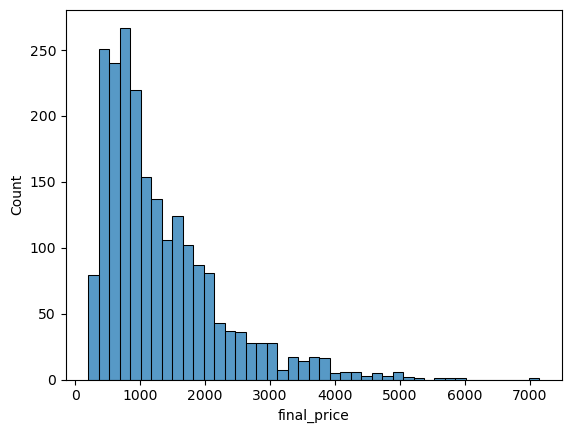

In [12]:
sns.histplot(df['final_price'])

### Question 1

There's one column with missing values. What is it?

* `'ram'`
* `'storage'`
* `'screen'`
* `'final_price'`

In [13]:
df.isna().sum()

ram            0
storage        0
screen         4
final_price    0
dtype: int64

In [31]:
df['screen'].value_counts()

screen
15.60    1009
14.00     392
16.00     174
17.30     161
13.30     131
16.10      48
17.00      33
13.00      27
15.00      21
13.50      19
13.40      19
11.60      16
14.20      14
12.30      13
14.10      11
13.60      11
16.20      10
15.30       8
10.50       7
14.40       6
12.40       6
15.40       5
12.00       4
18.00       3
14.50       3
13.90       2
12.50       1
10.10       1
10.95       1
Name: count, dtype: int64

answer: screen

### Question 2

What's the median (50% percentile) for variable `'ram'`?

- 8
- 16
- 24
- 32

In [14]:
df['ram'].describe()

count    2160.000000
mean       15.413889
std         9.867815
min         4.000000
25%         8.000000
50%        16.000000
75%        16.000000
max       128.000000
Name: ram, dtype: float64

In [15]:
df.ram.median()

16.0

### Prepare and split the dataset

* Shuffle the dataset (the filtered one you created above), use seed `42`.
* Split your data in train/val/test sets, with 60%/20%/20% distribution.

Use the same code as in the lectures

In [66]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

idx = np.arange(n)

np.random.seed(2)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [67]:
len(df_train), len(df_val), len(df_test)

(1296, 432, 432)

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 2 decimal digits using `round(score, 2)`
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [68]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.final_price.values
y_val = df_val.final_price.values
y_test = df_test.final_price.values

del df_train['final_price']
del df_val['final_price']
del df_test['final_price']

In [69]:
# funciton to train linear regressor
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [70]:
# funcion to calculate the rmse
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [71]:
# training with na replaced by 0
X_train = df_train.fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

X_val = df_val.fillna(0).values
y_pred = w0 + X_val.dot(w)

In [72]:
y_pred

array([2282.83050324,  939.07931716,  929.14589368, 6975.01318599,
       2315.94191484, 2329.18647947,  687.65446862,  452.1788586 ,
        697.5878921 , 1702.72144163,  929.14589368, 2329.18647947,
        687.65446862, 1295.35667115,  687.65446862,  452.1788586 ,
       1284.0367606 , 1702.72144163,  531.03820916,  687.65446862,
        410.29249663,  912.59018789, 1242.3784126 , 4469.15303461,
       2272.89707977,  687.65446862, 1755.69970018, 1855.59888581,
       1702.72144163, 1295.35667115, 1646.43204192,  687.65446862,
       1295.35667115, 1295.35667115, 2272.89707977,  687.65446862,
       2309.31963252, 1005.30214034,  929.14589368, 1229.13384797,
       2329.18647947, 1242.3784126 ,  929.14589368,  740.63272717,
       1295.35667115, 4512.19786968,  929.14589368, 1229.13384797,
        929.14589368,  652.99842623,  982.12415223, 1085.76215314,
        542.738143  , 1755.69970018, 1242.3784126 ,  687.65446862,
       1295.35667115, 1242.3784126 , 1702.72144163,  740.63272

In [73]:
# rmse of linear regressor trained with nulls preplaced with 0
round(rmse(y_val, y_pred), 2)

588.96

In [74]:
# training with na replaced by mean of screen
fill_value = df_train['screen'].mean()
X_train = df_train.fillna(fill_value).values

w0, w = train_linear_regression(X_train, y_train)

X_val = df_val.fillna(fill_value).values
y_pred = w0 + X_val.dot(w)

In [75]:
# rmse of linear regressor trained with nulls replaced with mean 
round(rmse(y_val, y_pred), 2)

588.88

I had thought they were equally good but that was because I had normalized the targets with log1p.  without normalizing the targets the method of replacing missing values with the mean of the training data actually was very slighly better than the method of filling with 0.

answer: Both are equally good

### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 2 decimal digits.
* Which `r` gives the best RMSE?

If there are multiple options, select the smallest `r`.

Options:

- 0
- 0.01
- 1
- 10
- 100

In [76]:
def prepare_X(df):
    df = df.copy()
    
    df = df.fillna(0)
    X = df.values

    return X

In [79]:
df_train.isna().sum()

ram        0
storage    0
screen     3
dtype: int64

In [80]:
df_val.isna().sum()

ram        0
storage    0
screen     0
dtype: int64

In [81]:
df_test.isna().sum()

ram        0
storage    0
screen     1
dtype: int64

In [82]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [83]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 2)
    
    print(f"r: {r} ---> rmse: {score}")

r: 0 ---> rmse: 588.96
r: 0.01 ---> rmse: 588.95
r: 0.1 ---> rmse: 588.93
r: 1 ---> rmse: 588.75
r: 5 ---> rmse: 588.34
r: 10 ---> rmse: 588.17
r: 100 ---> rmse: 588.21


answer: 10

### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 19.176
- 29.176
- 39.176
- 49.176

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.

In [84]:
def split_df(df, test_split=0.2, seed=42):
    df = df.copy()
    df = df.fillna(0)
    
    n = len(df)
    n_val = int(n * test_split)
    n_test = int(n * test_split)
    n_train = n - n_val - n_test
    
    df_train = df.iloc[:n_train]
    df_val = df.iloc[n_train:n_train+n_val]
    df_test = df.iloc[n_train+n_val:]
    
    idx = np.arange(n)
    
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    # y_train = np.log1p(df_train.final_price.values)
    # y_val = np.log1p(df_val.final_price.values)
    # y_test = np.log1p(df_test.final_price.values)

    y_train = df_train.final_price.values
    y_val = df_val.final_price.values
    y_test = df_test.final_price.values
    
    del df_train['final_price']
    del df_val['final_price']
    del df_test['final_price']

    return df_train, df_val, df_test, y_train, y_val, y_test

In [86]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = split_df(df, seed=seed)
    X_train = df_train.values
    X_val = df_val.values
    
    w0, w = train_linear_regression(X_train, y_train)
    
    y_pred = w0 + X_val.dot(w)
    rmse_score = rmse(y_val, y_pred)
    scores.append(rmse_score)
    print(f"seed: {seed} ----> rmse: {rmse_score}")

round(np.std(scores), 3)
    
    

seed: 0 ----> rmse: 565.4520868771004
seed: 1 ----> rmse: 636.798542305673
seed: 2 ----> rmse: 588.9558697907955
seed: 3 ----> rmse: 597.8148920012511
seed: 4 ----> rmse: 571.9627915111033
seed: 5 ----> rmse: 573.2383256618967
seed: 6 ----> rmse: 647.3438328407198
seed: 7 ----> rmse: 550.4398184485973
seed: 8 ----> rmse: 587.3335036169941
seed: 9 ----> rmse: 576.1017929433127


29.176

I didn't get to the right answer for a bit because I had used the log1p to normalized the targets even thought was never mentioned
in the instructions.  BY removing that I was able to get an anser that was in the choices

answer: 29.176

### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 598.60
- 608.60
- 618.60
- 628.60

In [121]:
def split_df_2(df, test_split=0.2, seed=42):
    df = df.copy()
    df = df.fillna(0)
    
    n = len(df)
    n_val = int(n * test_split)
    n_test = int(n * test_split)
    n_train = n - n_val - n_test
    
    # df_train = df.iloc[:n_train]
    # df_val = df.iloc[n_train:n_train+n_val]
    # df_test = df.iloc[n_train+n_val:]
    
    idx = np.arange(n)
    
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train + n_val]]
    #df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    #df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    # y_train = np.log1p(df_train.final_price.values)
    # y_val = np.log1p(df_val.final_price.values)
    # y_test = np.log1p(df_test.final_price.values)

    y_train = df_train.final_price.values
    # y_val = df_val.final_price.values
    y_test = df_test.final_price.values
    
    del df_train['final_price']
    # del df_val['final_price']
    del df_test['final_price']

    return df_train, df_test, y_train, y_test

In [122]:
seed = 9
df_train, df_test, y_train, y_test = split_df_2(df, seed=seed)

In [123]:
len(df_train), len(y_train)

(1728, 1728)

In [124]:
len(df_test), len(y_test)

(432, 432)

In [128]:

X_train = df_train.values
X_test = df_test.values

w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

y_pred = w0 + X_test.dot(w)
test_rmse = round(rmse(y_test, y_pred), 5)
print(f"rmse on test data: {test_rmse}")

rmse on test data: 608.60998


answer: 608.60